# NASA Turbofan FD001 – Models with Top-Correlated Features

This notebook reproduces the regression and tree-based models from the original FD001 notebook, but **reduces the feature vector** to the top 10–15 features most correlated with Remaining Useful Life (RUL) to help control overfitting.

In [1]:
# Imports and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = os.path.join('..', 'data', 'CMAPSSData')
TRAIN_FILE = os.path.join(DATA_DIR, 'train_FD001.txt')

print('Train path:', TRAIN_FILE)

Train path: ..\data\CMAPSSData\train_FD001.txt


In [2]:
# 1. Load and prepare NASA Turbofan FD001 dataset


COLUMNS = [
    'unit', 'time',
    'setting_1', 'setting_2', 'setting_3',
    's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10',
    's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21',
]


def load_cmapss_fd001(train_path: str) -> pd.DataFrame:
    df = pd.read_csv(train_path, sep=' ', header=None)
    # Drop all-empty columns created by trailing spaces
    df = df.dropna(axis=1, how='all')
    df.columns = COLUMNS
    return df


train_df = load_cmapss_fd001(TRAIN_FILE)
print('Train shape:', train_df.shape)


# Sort and compute Remaining Useful Life (RUL)
train_df = train_df.sort_values(['unit', 'time']).reset_index(drop=True)
max_time_per_unit = train_df.groupby('unit')['time'].transform('max')
train_df['RUL'] = max_time_per_unit - train_df['time']


# Apply RUL capping to reduce the impact of very early cycles
RUL_CAP = 125
train_df['RUL_capped'] = np.minimum(train_df['RUL'], RUL_CAP)


print('RUL stats (before cap):')
print(train_df['RUL'].describe()[['min', 'max', 'mean']])
print('RUL stats (after cap at 125):')
print(train_df['RUL_capped'].describe()[['min', 'max', 'mean']])

Train shape: (20631, 26)
RUL stats (before cap):
min       0.000000
max     361.000000
mean    107.807862
Name: RUL, dtype: float64
RUL stats (after cap at 125):
min       0.000000
max     125.000000
mean     86.829286
Name: RUL_capped, dtype: float64


## Select top-correlated features (10–15) with RUL
We compute the absolute Pearson correlation between each candidate feature and RUL, sort them, and select the top 15 features (within the requested 10–15 range). These will define the reduced feature vector for all models in this notebook.

In [3]:
# 2. Split into train/validation/test at engine (unit) level and select top-correlated features


# Split by engine_id (unit) to avoid leakage between splits
unit_ids = np.sort(train_df['unit'].unique())
print('Total number of engines (units):', len(unit_ids))


# First split into train vs temp (val+test)
train_units, temp_units = train_test_split(
    unit_ids,
    test_size=0.4,
    random_state=42,
    shuffle=True,
    stratify=None,
 )


# Then split temp into validation and test
val_units, test_units = train_test_split(
    temp_units,
    test_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=None,
 )


def subset_by_units(df: pd.DataFrame, units) -> pd.DataFrame:
    return df[df['unit'].isin(units)].copy()


train_df_split = subset_by_units(train_df, train_units)
val_df_split = subset_by_units(train_df, val_units)
test_df_split = subset_by_units(train_df, test_units)


print('Engines per split -> train:', len(train_units),
      'val:', len(val_units),
      'test:', len(test_units))
print('Rows per split    -> train:', len(train_df_split),
      'val:', len(val_df_split),
      'test:', len(test_df_split))


# Sensor columns and constant / low-variance removal based on TRAIN split only
sensor_cols = [c for c in train_df.columns if c.startswith('s_')]


constant_sensors = [c for c in sensor_cols if train_df_split[c].nunique() <= 1]
low_var_threshold = 1e-3
low_variance_sensors = [c for c in sensor_cols if train_df_split[c].std() < low_var_threshold]


dropped_sensors = sorted(set(constant_sensors) | set(low_variance_sensors))
print('Constant sensors (dropped):', constant_sensors)
print('Low-variance sensors (dropped):', low_variance_sensors)
print('Total dropped sensor features:', len(dropped_sensors))


feature_cols_base = [
    c for c in train_df.columns
    if c not in ['RUL', 'RUL_capped', 'time', 'unit']
 ]
feature_cols_base = [c for c in feature_cols_base if c not in dropped_sensors]
print('Number of base features after dropping:', len(feature_cols_base))
print('Base feature columns:', feature_cols_base)


# Compute correlation with capped RUL on the TRAIN split only
corr = train_df_split[feature_cols_base + ['RUL_capped']].corr()['RUL_capped'].drop('RUL_capped')
corr_abs = corr.abs().sort_values(ascending=False)


TOP_K = 15  # within requested 10–15 range
TOP_K = min(TOP_K, len(corr_abs))
top_features = corr_abs.head(TOP_K).index.tolist()


print('Top correlated features with capped RUL (by |correlation|):')
display(corr.loc[top_features].to_frame('corr_with_RUL_capped'))


# Final feature matrices and targets (using capped RUL)
X_train = train_df_split[top_features]
y_train = train_df_split['RUL_capped']


X_val = val_df_split[top_features]
y_val = val_df_split['RUL_capped']


X_test = test_df_split[top_features]
y_test = test_df_split['RUL_capped']


print('Reduced feature count:', X_train.shape[1])
print('Reduced feature set:', top_features)


# Preprocessing: standardize features (fit on train only inside the Pipeline)
preprocess = Pipeline(steps=[
    ('scaler', StandardScaler()),
])

Total number of engines (units): 100
Engines per split -> train: 60 val: 20 test: 20
Rows per split    -> train: 12270 val: 4236 test: 4125
Constant sensors (dropped): ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
Low-variance sensors (dropped): ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
Total dropped sensor features: 6
Number of base features after dropping: 18
Base feature columns: ['setting_1', 'setting_2', 'setting_3', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
Top correlated features with capped RUL (by |correlation|):


,corr_with_RUL_capped
s_11,-0.783884
s_4,-0.759891
s_12,0.754601
s_7,0.741687
s_15,-0.726919
s_20,0.712904
s_21,0.711436
s_17,-0.687418
s_2,-0.681264
s_3,-0.664170


Reduced feature count: 15
Reduced feature set: ['s_11', 's_4', 's_12', 's_7', 's_15', 's_20', 's_21', 's_17', 's_2', 's_3', 's_8', 's_13', 's_9', 's_14', 's_6']


In [4]:
# 3. Metric helpers and sanity checks


print('Train size (rows):', X_train.shape[0])
print('Validation size (rows):', X_val.shape[0])
print('Test size (rows):', X_test.shape[0])


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


def print_metrics(name, split, metrics):
    print(
        f'{name} ({split}) -> MAE={metrics["MAE"]:.2f}, '
        f'RMSE={metrics["RMSE"]:.2f}, R2={metrics["R2"]:.3f}'
    )

Train size (rows): 12270
Validation size (rows): 4236
Test size (rows): 4125


## Linear Regression with reduced feature set

Linear (train) -> MAE=17.43, RMSE=21.28, R2=0.740
Linear (val) -> MAE=17.96, RMSE=21.85, R2=0.724
Linear (test) -> MAE=17.44, RMSE=22.25, R2=0.715


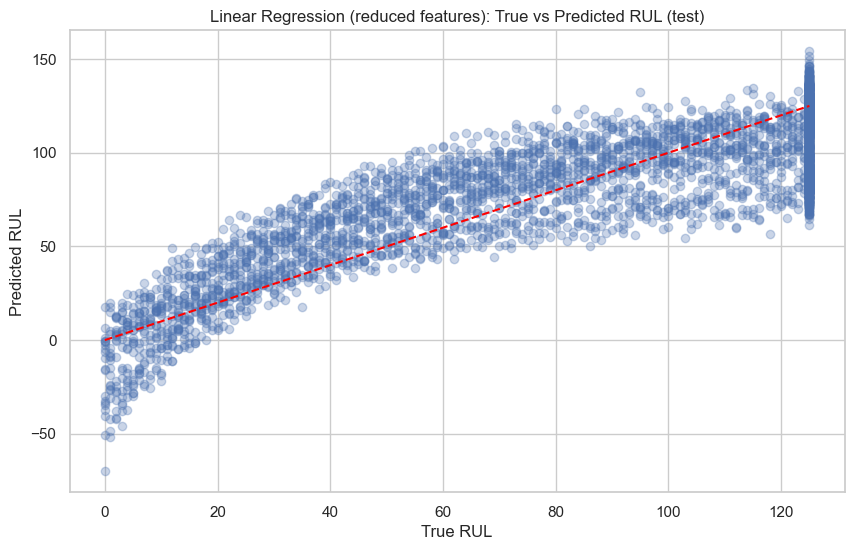

In [5]:
# 4. Linear Regression

lin_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression()),
])

lin_pipeline.fit(X_train, y_train)

y_train_pred_lr = lin_pipeline.predict(X_train)
y_val_pred_lr = lin_pipeline.predict(X_val)
y_test_pred_lr = lin_pipeline.predict(X_test)

metrics_lr_train = regression_metrics(y_train, y_train_pred_lr)
metrics_lr_val = regression_metrics(y_val, y_val_pred_lr)
metrics_lr_test = regression_metrics(y_test, y_test_pred_lr)

print_metrics('Linear', 'train', metrics_lr_train)
print_metrics('Linear', 'val', metrics_lr_val)
print_metrics('Linear', 'test', metrics_lr_test)

# True vs predicted on test
fig, ax = plt.subplots()
ax.scatter(y_test, y_test_pred_lr, alpha=0.3)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
ax.set_xlabel('True RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title('Linear Regression (reduced features): True vs Predicted RUL (test)')
plt.show()

## Ridge Regression with hyperparameter tuning (reduced features)

Best Ridge alpha: 10.0
Best Ridge CV score (MAE): 17.66852339459351
Ridge (train) -> MAE=17.43, RMSE=21.28, R2=0.740
Ridge (val) -> MAE=17.96, RMSE=21.85, R2=0.724
Ridge (test) -> MAE=17.44, RMSE=22.25, R2=0.715


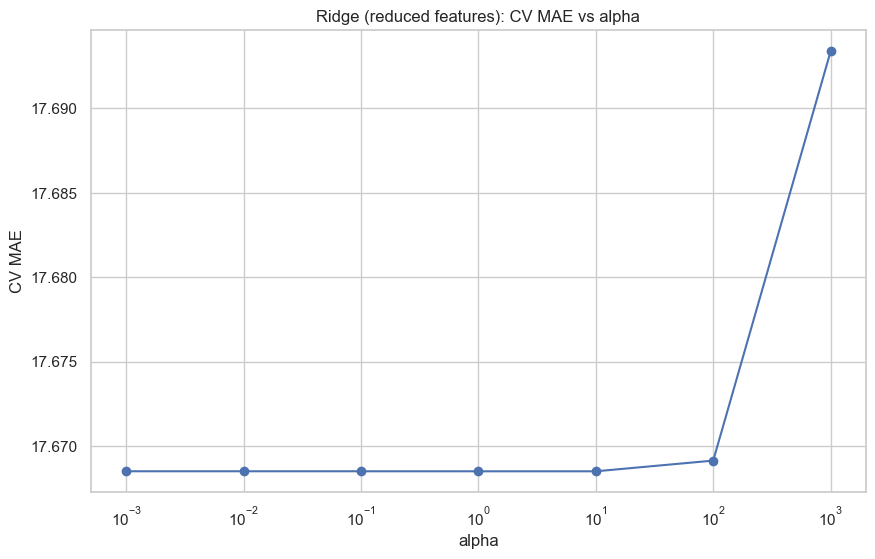

In [6]:
# 5. Ridge Regression with hyperparameter tuning

ridge_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', Ridge()),
])

alphas = np.logspace(-3, 3, 7)
param_grid_ridge = {'model__alpha': alphas}

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid_ridge,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=0,
)

ridge_search.fit(X_train, y_train)

print('Best Ridge alpha:', ridge_search.best_params_['model__alpha'])
print('Best Ridge CV score (MAE):', -ridge_search.best_score_)

ridge_best = ridge_search.best_estimator_

y_train_pred_ridge = ridge_best.predict(X_train)
y_val_pred_ridge = ridge_best.predict(X_val)
y_test_pred_ridge = ridge_best.predict(X_test)

metrics_ridge_train = regression_metrics(y_train, y_train_pred_ridge)
metrics_ridge_val = regression_metrics(y_val, y_val_pred_ridge)
metrics_ridge_test = regression_metrics(y_test, y_test_pred_ridge)

print_metrics('Ridge', 'train', metrics_ridge_train)
print_metrics('Ridge', 'val', metrics_ridge_val)
print_metrics('Ridge', 'test', metrics_ridge_test)

# Optional: visualize CV MAE vs alpha
mean_test_scores = ridge_search.cv_results_['mean_test_score']
mean_mae = -mean_test_scores
fig, ax = plt.subplots()
ax.semilogx(alphas, mean_mae, marker='o')
ax.set_xlabel('alpha')
ax.set_ylabel('CV MAE')
ax.set_title('Ridge (reduced features): CV MAE vs alpha')
plt.show()

## Lasso Regression with feature selection (reduced features)

In [7]:
# 6. Lasso Regression with feature selection

lasso_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', Lasso(max_iter=10000)),
])

lasso_alphas = np.logspace(-3, 1, 5)
param_grid_lasso = {'model__alpha': lasso_alphas}

lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid=param_grid_lasso,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=0,
)

lasso_search.fit(X_train, y_train)

print('Best Lasso alpha:', lasso_search.best_params_['model__alpha'])
print('Best Lasso CV score (MAE):', -lasso_search.best_score_)

lasso_best = lasso_search.best_estimator_

y_train_pred_lasso = lasso_best.predict(X_train)
y_val_pred_lasso = lasso_best.predict(X_val)
y_test_pred_lasso = lasso_best.predict(X_test)

metrics_lasso_train = regression_metrics(y_train, y_train_pred_lasso)
metrics_lasso_val = regression_metrics(y_val, y_val_pred_lasso)
metrics_lasso_test = regression_metrics(y_test, y_test_pred_lasso)

print_metrics('Lasso', 'train', metrics_lasso_train)
print_metrics('Lasso', 'val', metrics_lasso_val)
print_metrics('Lasso', 'test', metrics_lasso_test)

# Inspect non-zero coefficients (selected features)
lasso_coefs = lasso_best.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': top_features, 'coef': lasso_coefs})
non_zero = coef_df[coef_df['coef'] != 0.0].copy()

if not non_zero.empty:
    non_zero['abs_coef'] = non_zero['coef'].abs()
    non_zero = non_zero.sort_values('abs_coef', ascending=False)
    display(non_zero)
else:
    print('Lasso set all coefficients to zero for the chosen alpha.')

Best Lasso alpha: 0.001
Best Lasso CV score (MAE): 17.668456284460458
Lasso (train) -> MAE=17.43, RMSE=21.28, R2=0.740
Lasso (val) -> MAE=17.96, RMSE=21.85, R2=0.724
Lasso (test) -> MAE=17.44, RMSE=22.25, R2=0.715


,feature,coef,abs_coef
0,s_11,-6.316900,6.316900
12,s_9,-6.128506,6.128506
2,s_12,5.050244,5.050244
3,s_7,4.546692,4.546692
1,s_4,-3.833309,3.833309
4,s_15,-3.379937,3.379937
13,s_14,-3.324755,3.324755
5,s_20,2.800559,2.800559
6,s_21,2.582993,2.582993
7,s_17,-2.281217,2.281217


## Tree-based models (Random Forest & Gradient Boosting) with reduced feature set

In [8]:
# 7. Tree-based models: Random Forest and Gradient Boosting (tuned, reduced overfitting)


# --- Random Forest with hyperparameter tuning to reduce overfitting ---


rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
    )),
])


param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [5, 10, 20],
    'model__min_samples_leaf': [2, 5, 10],
    'model__max_features': ['sqrt', 0.5],
}


rf_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid_rf,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
 )


rf_search.fit(X_train, y_train)


print('Best RandomForest parameters:', rf_search.best_params_)
print('Best RandomForest CV score (MAE):', -rf_search.best_score_)


rf_best = rf_search.best_estimator_


y_train_pred_rf = rf_best.predict(X_train)
y_val_pred_rf = rf_best.predict(X_val)
y_test_pred_rf = rf_best.predict(X_test)


metrics_rf_train = regression_metrics(y_train, y_train_pred_rf)
metrics_rf_val = regression_metrics(y_val, y_val_pred_rf)
metrics_rf_test = regression_metrics(y_test, y_test_pred_rf)


print_metrics('RandomForest', 'train', metrics_rf_train)
print_metrics('RandomForest', 'val', metrics_rf_val)
print_metrics('RandomForest', 'test', metrics_rf_test)


# Feature importance from tuned Random Forest (for interpretation)
rf_feature_importances = rf_best.named_steps['model'].feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': top_features,
    'importance': rf_feature_importances,
}).sort_values('importance', ascending=False)
print('RandomForest feature importances (descending):')
display(rf_importance_df)


# --- Gradient Boosting with hyperparameter tuning ---


gb_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', GradientBoostingRegressor(
        random_state=42,
    )),
])


param_grid_gb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3],
}


gb_search = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid_gb,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
 )


gb_search.fit(X_train, y_train)


print('Best GradientBoosting parameters:', gb_search.best_params_)
print('Best GradientBoosting CV score (MAE):', -gb_search.best_score_)


gb_best = gb_search.best_estimator_


y_train_pred_gb = gb_best.predict(X_train)
y_val_pred_gb = gb_best.predict(X_val)
y_test_pred_gb = gb_best.predict(X_test)


metrics_gb_train = regression_metrics(y_train, y_train_pred_gb)
metrics_gb_val = regression_metrics(y_val, y_val_pred_gb)
metrics_gb_test = regression_metrics(y_test, y_test_pred_gb)


print_metrics('GradientBoosting', 'train', metrics_gb_train)
print_metrics('GradientBoosting', 'val', metrics_gb_val)
print_metrics('GradientBoosting', 'test', metrics_gb_test)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best RandomForest parameters: {'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best RandomForest CV score (MAE): 13.77216415409786
RandomForest (train) -> MAE=10.69, RMSE=14.73, R2=0.875
RandomForest (val) -> MAE=14.27, RMSE=18.57, R2=0.800
RandomForest (test) -> MAE=14.35, RMSE=19.18, R2=0.788
RandomForest feature importances (descending):


,feature,importance
0,s_11,0.376165
1,s_4,0.169627
2,s_12,0.118944
12,s_9,0.087782
3,s_7,0.073484
4,s_15,0.054711
13,s_14,0.049883
6,s_21,0.019282
5,s_20,0.012238
8,s_2,0.011168


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best GradientBoosting parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300}
Best GradientBoosting CV score (MAE): 13.77625330562825
GradientBoosting (train) -> MAE=12.33, RMSE=17.03, R2=0.833
GradientBoosting (val) -> MAE=14.41, RMSE=18.84, R2=0.795
GradientBoosting (test) -> MAE=14.55, RMSE=19.42, R2=0.783
